# Set Up

## Libraries

In [169]:
import sys
sys.path.append(r"C:\GitHubRepos\APSIMTools\GraphLib")

%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
import subprocess
import shutil
import warnings
from matplotlib.lines import Line2D
from pandas.api.types import is_numeric_dtype
from itertools import cycle


# graph models
from apsim_tools.graphing import (
    plot_obs_pred_by_branch,
    plot_stage_timeseries
)

from apsim_tools.style import ( 
    Colors, 
    Markers,
    Lines
)

from apsim_tools.runner import (
reset_repo,
checkout_branch,
build_apsim,
run_apsim
)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Grouping functions

In [88]:
def value_at_stage(target, tol_low, tol_high):

    def fn(df, variable):

        window = df.loc[
            (df["Wheat.Phenology.Stage"] > tol_low) &
            (df["Wheat.Phenology.Stage"] < tol_high)
        ]

        window = window[window[variable].notna()]

        if window.empty:
            return np.nan

        idx = (
            window["Wheat.Phenology.Stage"]
            .sub(target)
            .abs()
            .idxmin()
        )

        return window.loc[idx, variable]

    return fn

def MeanValue(df, variable):
    return df[variable].mean()

def SumValues(df, variable):
    return df[variable].sum()

## data class

In [89]:
@dataclass
class AnalysisData:

    pred: pd.DataFrame
    obs: pd.DataFrame

    def derive(self, name, fn):

        derived = fn(self.obs)
    
        if not isinstance(derived, pd.Series):
            derived = pd.Series(
                derived,
                index=self.obs.index)
    
        if name in self.obs.columns:
            self.obs[name] = (
                self.obs[name]
                .combine_first(derived))
    
        else:
            self.obs[name] = derived

    def filter(self, fn):

        filterMask = fn(self.obs)

        return filterMask

    def fill_triangular_set(self, top, left, right):

        cols = [top, left, right]
    
        missing = [c for c in cols if c not in self.obs.columns]
    
        if missing:
            print(f"Missing columns: {missing}")
            return self
    
        a = self.obs[top]
        b = self.obs[left]
        c = self.obs[right]
    
        # fill top
        self.obs[top] = a.combine_first(b * c)
    
        # fill left
        self.obs[left] = b.combine_first(
            a.div(c.replace(0, np.nan))
        )
    
        # fill right
        self.obs[right] = c.combine_first(
            a.div(b.replace(0, np.nan))
        )
        
    def aggregate_sim_values(self, var, outName, source="obs", fn = MeanValue, filter_fn = None):
        df = getattr(self, source)
        mask = pd.Series(True, index=df.index)
        if filter_fn:
            mask = filter_fn(df)
    
        grouped = (df.loc[mask].groupby("Simulation.Name"))
    
        values = grouped.apply(lambda g: fn(g, var))
    
        self.obs[outName] = (self.obs["Simulation.Name"].map(values))

    def summary(self):
        print(f"Pred rows : {len(self.pred):,}")
        print(f"Obs rows  : {len(self.obs):,}")

        print(f"Pred sims : {self.pred['SimulationID'].nunique():,}")
        print(f"Obs sims  : {self.obs['SimulationID'].nunique():,}")


ANALYSIS_KEYS = [
    "file",
    "SimulationID",
    "Clock.Today"
]

## Load branch data function

In [90]:
def load_branch_data(config, apply_fn):
    git_branch = config['git_branch']

    if config['run_sims'] == True:
        reset_repo(config)
        checkout_branch(git_branch, config)
        build_apsim(config)

    pred_frames = []
    obs_frames = []

    for sim in config["sim_files"]:

        db = sim.parent / f"{sim.stem}.db"

        # --- Run APSIM ---
        if config['run_sims'] == True:
            print("")
            print(f"▶ Running APSIM [{git_branch}]: {sim.name}")
            run_apsim(sim, config, apply_fn)

            original_db = sim.with_suffix(".db")
            hold_db = sim.parent / f"{sim.stem}_{git_branch}_hold.db"

            shutil.copyfile(original_db, hold_db)

        if not db.exists():
            print(f"❌ DB not created: {db}")
            continue

        # ======================================================
        # ✅ READ DATABASE
        # ======================================================
        with sqlite3.connect(db) as conn:

            tables = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table';",
                conn
            )["name"].tolist()

            print(f"{sim.name} tables: {tables}")

            # ---------------------------------------------
            # ✅ Observed
            # ---------------------------------------------
            obs = None
            if config["obs_table_name"] in tables:
                obs = pd.read_sql(f"SELECT * FROM [{config['obs_table_name']}]", conn)
                obs = obs.drop(columns=["SimulationName"], errors="ignore")
                
            # ---------------------------------------------
            # ✅ Predictions
            # ---------------------------------------------
            pred = None
            if config["pred_table_name"] in tables:
                pred = pd.read_sql(f"SELECT * FROM [{config['pred_table_name']}]", conn)
                
            if pred is None and obs is None:
                continue
            
            # ---------------------------------------------
            # ✅ Diagnose SimulationID alignment
            # ---------------------------------------------
            if pred is not None and obs is not None:

                pred_ids = set(pred["SimulationID"].dropna().unique())
                obs_ids = set(obs["SimulationID"].dropna().unique())

                # --- Diagnostics (optional but useful) ---
                missing_ids = pred_ids - obs_ids
                if missing_ids:
                    print(f"\n⚠️ Missing observed simulations in {sim.name}: {len(missing_ids)}")

                extra_obs_ids = obs_ids - pred_ids
                if extra_obs_ids:
                    print(f"\n⚠️ Dropping unmatched observed simulations in {sim.name}: {len(extra_obs_ids)}")

            # ---------------------------------------------
            # ✅ Attach metadata (branch, file)
            # ---------------------------------------------
            if pred is not None:
                pred["file"] = sim.name
                pred["branch"] = git_branch
                pred_frames.append(pred)
                if "Clock.Today" in pred.columns:
                    pred["Clock.Today"] = pd.to_datetime(pred["Clock.Today"])

            if obs is not None:
                obs["file"] = sim.name
                obs_frames.append(obs)
                obs["branch"] = git_branch
                if "Clock.Today" in obs.columns:
                    obs["Clock.Today"] = pd.to_datetime(obs["Clock.Today"])

    if not obs_frames:
        raise RuntimeError(f"No obs data loaded")
    if not pred_frames:
        raise RuntimeError(f"No pred data loaded")
    
    return AnalysisData(
                        pred=pd.concat(pred_frames, ignore_index=True),
                        obs=pd.concat(obs_frames, ignore_index=True)
                        )

# Read in data

## Set branch and file data

In [91]:
REPO_PATH = Path(r"C:\GitHubRepos\ApsimX")

SIM_FILES = [
    #Path(REPO_PATH) / 'Prototypes/Lentil/Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/FAHMA/FAHMA_Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2019_NSW_Greenethorpe_Mixed_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Kalkee_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Riverton_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_Methul_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Pinery_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Dooen_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Qld_Gatton_Mixed_Light.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_NSW_Greenethorpe_Mixed_NFix.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.apsimx'
]


CONFIG = {
    "git_branch":  "Lentil_Model_NaPA",
    "run_sims": False,
    "sim_files": SIM_FILES,
    "repo_path": Path(r"C:\GitHubRepos\ApsimX"),
    "apsim_exe": r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe",
    "apsim_solution": r"C:\GitHubRepos\ApsimX\ApsimX.sln",
    "obs_table_name": "Observed",
    "pred_table_name": "AnalysisReport"
}

## Write apply file

In [92]:
# this function writes and apply file that the CLI
def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """
    report_library = r"C:\GitHubRepos\APSIMTools\Lentil analysis\Report_lib.apsimx"
    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    lines.append("delete all [Report]")
    lines.append(f"add [AnalysisReport] from {report_library} to all [Zone]")

    # ---------------------------------------------
    # remove predicted Observed tables
    # ---------------------------------------------
    lines.append("delete all [PredictedObserved]")
    
    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

## Read in data

In [106]:
data = load_branch_data(CONFIG, write_apply_file)

FAHMA_Lentil.apsimx tables: ['_Factors', '_InitialConditions', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', 'HarvestObsPred', '_PredictedObserved', 'AnalysisReport', '_Units', 'DailyObsPred', 'Observed']
2019_NSW_Greenethorpe_Mixed_Detailed.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', '_Units', '_PredictedObserved', 'AnalysisReport', 'Observed']

⚠️ Missing observed simulations in 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx: 9

⚠️ Dropping unmatched observed simulations in 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx: 180
2022_Vic_Kalkee_Lentil_Detailed.apsimx tables: ['_Factors', '_InitialConditions', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', 'HarvestObsPred', '_PredictedObserved', 'AnalysisReport', '_Units', 'DailyObsPred', 'Observed']

⚠️ Dropping unmatched observed simulations in 2022_Vic_Kalkee_Lentil_Detailed.apsimx: 172
2022_SA_Riverton_Lentil_Detailed.apsimx tab

# Tidy up observed data frame

## deal with unuseful and duplicate columns

In [111]:
def drop_unused_cols(data):
    Keep_columns = [
    'SimulationID',
    'Clock.Today',
    'Lentil.Phenology.CurrentStageName',
    'Lentil.Phenology.Stage',
    'Lentil.Phenology.EmergenceDAS',
    'Lentil.Phenology.MaturityDAS',
    'Lentil.Phenology.StartFloweringDAS',
    'Lentil.Phenology.StartPoddingDAS',
    'Lentil.AboveGround.Wt',
    'Lentil.Stem.Wt',
    'Lentil.Fruit.Wt',
    'Lentil.Pod.Wt',
    'Lentil.Leaf.Wt',
    'Lentil.Leaf.Canopy.SpecificArea',
    'Lentil.Grain.Wt',
    'Lentil.Grain.Number',
    'Lentil.Grain.Size',
    'Lentil.Grain.HarvestIndex',
    'Lentil.Leaf.Canopy.CoverTotal',
    'Lentil.SowingData.Cultivar',
    'file',
    'branch',
    'Lentil.Phenology.StartBuddingDAS',
    'Lentil.Leaf.NodeNumber',
    'Lentil.AboveGround.N',
    'Lentil.Pod.Number',
    'Lentil.Pod.GrainNumber',
    'Lentil.SowingData.Population']
    
    data.obs = data.obs.loc[:,Keep_columns].copy()

    remove_cols = [
    'branch',
    'file',
    'SimulationID',
    'Clock.Today',
    'Lentil.Phenology.CurrentStageName',
    ]
    
    numeric_cols = [
        c for c in Keep_columns
        if c not in remove_cols
    ]

    for c in numeric_cols:
        data.obs[c] = pd.to_numeric(data.obs[c], errors="coerce")
    return data

data = drop_unused_cols(data)

## Tidy up indexing in observed file

In [113]:
def fill_obs_metadata(data):

    cols = [
        "Experiment",
        "Simulation.Name",
        "Lentil.SowingData.Cultivar",
        "Lentil.Population",
        "IWeather.Latitude",
        "IWeather.Longitude"
    ]

    keys = ["file", "SimulationID"]

    meta = (
        data.pred
        [keys + cols]
        .drop_duplicates()
    )

    data.obs = (
        data.obs
        .drop(columns=cols, errors="ignore")
        .merge(meta, on=keys, how="left")
    )

    return data

data = fill_obs_metadata(data)

## add in custom indexing

In [ ]:
# DevMap = {
# "Accroc":"Winter",
# "Adv08_0008":"Winter",
# "Anapurna":"Winter",
# "Ararat":"Spring",
# "Atlanta":"Spring",
# "Axe":"Spring",
# "Batavia":"Spring",
# "Battenspring":"Spring",
# "Batten":"Winter",
# "Beaufort":"Spring",
# "Bennett":"Winter",
# "BigRed":"Winter",
# "Bolac":"Spring",
# "Braewood":"Spring",
# "Calabro":"Winter",
# "Calingiri":"Spring",
# "Catalina":"Spring",
# "Catapult":"Spring",
# "Cesario":"Winter",
# "Claire":"Winter",
# "Conquest":"Spring",
# "Corack":"Spring",
# "Crusader":"Spring",
# "Crw247":"Spring",
# "Cutlass":"Spring",
# "Dekan":"Spring",
# "Derrimut":"Spring",
# "Discovery":"Spring",
# "Drysdale":"Spring",
# "Eaglehawk":"Spring",
# "Einstein":"Winter",
# "Ellison":"Spring",
# "Forrest":"Spring",
# "Gamenya":"Spring",
# "Gauntlet":"Spring",
# "Gladius":"Spring",
# "Gorgan":"Spring",
# "Graham":"Winter",
# "Gregory":"Spring",
# "Gutha":"Spring",
# "H45":"Spring",
# "H46":"Spring",
# "Har1685":"Spring",
# "Hartog":"Spring",
# "Hume":"Spring",
# "Illabo":"Winter",
# "Istabraq":"Spring",
# "Janz":"Spring",
# "Kellalac":"Spring",
# "Kennedy":"Spring",
# "Kerrin":"Winter",
# "Keyu13":"Spring",
# "Kinsei":"Spring",
# "Kittyhawk":"Winter",
# "Konya":"Spring",
# "Lancer":"Spring",
# "Lincoln":"Spring",
# "Livingston":"Spring",
# "Mace":"Spring",
# "Magenta":"Spring",
# "Manning":"Winter",
# "Matong":"Spring",
# "Meering":"Spring",
# "Mercury":"Spring",
# "Merinda":"Spring",
# "Mowhawk":"Winter",
# "Nighthawk":"Spring",
# "Osprey":"Winter",
# "Otane":"Spring",
# "Ouyen":"Spring",
# "Pascal":"Spring",
# "Peake":"Spring",
# "Relay":"Winter",
# "Revenue":"Winter",
# "Rockstar":"Spring",
# "Rongotea":"Spring",
# "Rosario":"Spring",
# "Rosella":"Winter",
# "Ruby":"Spring",
# "Savannah":"Winter",
# "Scepter":"Spring",
# "Scout":"Spring",
# "Scythe":"Spring",
# "Sorrial":"Winter",
# "Spear":"Spring",
# "Spitfire":"Spring",
# "Stockade":"Spring",
# "Strzelecki":"Spring",
# "Sunbri":"Spring",
# "Sunmaster":"Spring",
# "Sunstate":"Spring",
# "Suntop":"Spring",
# "Trojan":"Spring",
# "Uom001_3_47":"Winter",
# "Uom001_9_1":"Winter",
# "Ventura":"Spring",
# "Voltron":"Winter",
# "Wakanui":"Winter",
# "Waugh":"Winter",
# "Wedgetail":"Winter",
# "Whistler":"Winter",
# "Wilgoyne":"Spring",
# "Wills":"Spring",
# "Wyalkatchem":"Spring",
# "Wylah":"Winter",
# "Yecora":"Spring",
# "Yitpi":"Spring",
# "Young":"Spring",
# "Zanzibar":"Spring",
# "Zyatt":"Winter",
# }


# # Pack maps together ready to be inserted as indexes 
# additional_index_maps = {
#     "DevelopmentType": {
#         "source": "Wheat.SowingData.Cultivar",
#         "map": DevMap
#     }
# }

In [ ]:
# def add_index_maps(data, additional_index_maps):

#     for new_col, spec in additional_index_maps.items():

#         source_col = spec["source"]
#         mapping = spec["map"]

#         if source_col not in data.obs.columns:
#             print(
#                 f"Warning: '{source_col}' not found "
#                 f"for index '{new_col}'"
#             )
#             continue

#         data.obs[new_col] = (
#             data.obs[source_col]
#             .map(mapping)
#         )
        
#         data.pred[new_col] = (
#             data.pred[source_col]
#             .map(mapping)
#         )
#     return data

# data = add_index_maps(data, additional_index_maps)

# Merge predicted values in with observations 

## Merge simple variables

In [181]:
def first_nonblank(s):
    s = s.replace("", np.nan).dropna()
    return s.iloc[0] if len(s) else np.nan

def make_agg_dict(var):
    agg_dict = {'Simulation.Name':first_nonblank,
                 'Clock.Today':first_nonblank,
                 'Experiment':first_nonblank,
                 'Lentil.SowingData.Cultivar':first_nonblank,
                 'Lentil.Phenology.CurrentStageName':first_nonblank,
                  var:"mean"}
    return agg_dict

def get_ob_pred_harvest_data(var):
    
    indexRows = ['Simulation.Name','Clock.Today','Experiment','Lentil.SowingData.Cultivar','Lentil.Phenology.CurrentStageName']
    agg_dict = make_agg_dict(var)
    # get obs and pred data
    obsraw = data.obs[indexRows+[var]].dropna()
    predraw = data.pred[indexRows+[var]].dropna()

    # filter out harvest time data
    obsHarv = obsraw[obsraw["Lentil.Phenology.CurrentStageName"]=="HarvestRipe"]
    predHarv = predraw[predraw["Lentil.Phenology.CurrentStageName"]=="HarvestRipe"]
    
    # agregated to a single value per simulation
    obsMeans = obsHarv.groupby('Simulation.Name', as_index=False).agg(agg_dict).dropna(subset=[var])
    obsMeans.set_index('Simulation.Name',inplace=True)
    predMeans = predHarv.groupby('Simulation.Name', as_index=False).agg(agg_dict).dropna(subset=[var])
    predMeans.set_index('Simulation.Name',inplace=True)

    # Join together into a single data frame
    plotdata = obsMeans[['Experiment','Lentil.SowingData.Cultivar', var]]
    plotdata.columns = ['Experiment','Lentil.SowingData.Cultivar']+['obs']
    plotdata['pred'] = predMeans.reindex(obsMeans.index)[var]

    return plotdata

In [179]:
def plot_obs_pred(var,
    marker_by = "Experiment",
    color_by = "Lentil.SowingData.Cultivar",
    ax = None):
    
    plotdata = get_ob_pred_harvest_data(var)
    
    if ax is None:
        fig, ax = plt.subplots()
    
    marker_groups = plotdata[marker_by].drop_duplicates()
    marker_cycle = cycle(Markers.values())
    marker_map = {group: next(marker_cycle) for group in marker_groups}
    color_groups = plotdata[color_by].drop_duplicates()
    color_cycle = cycle(Colors.values())
    color_map = {group: next(color_cycle) for group in color_groups}
    for m in marker_groups:
        setdata = plotdata[plotdata[marker_by]==m]
        colors = setdata[color_by].apply(lambda c: color_map.get(c, 'grey'))
        plt.scatter(setdata['obs'],setdata['pred'],c=colors,marker=marker_map[m])


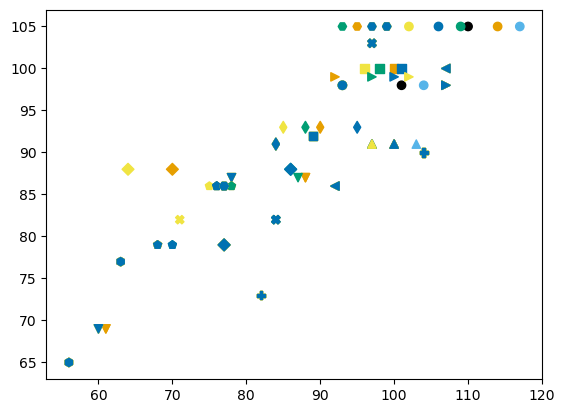

In [182]:
plot_obs_pred("Lentil.Phenology.StartBuddingDAS")

In [145]:
plotdata

,Experiment,Lentil.SowingData.Cultivar,obs,pred
Simulation.Name,,,,
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyAceWaterTrtRainFed,2022_NSW_Methul_Lentil_Satellite,Ace,8.0,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyBoltWaterTrtRainFed,2022_NSW_Methul_Lentil_Satellite,Bolt,8.0,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyGreenfieldWaterTrtRainFed,2022_NSW_Methul_Lentil_Satellite,Greenfield,8.0,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyHallmarkXTWaterTrtRainFed,2022_NSW_Methul_Lentil_Satellite,HallmarkXT,8.0,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyJumbo2WaterTrtRainFed,2022_NSW_Methul_Lentil_Satellite,Jumbo2,8.0,8.0
...,...,...,...,...
ForestHill25TOS1WaterTrtRainFedVarietyTerrier,ForestHill25,Terrier,6.0,6.0
ForestHill25TOS2WaterTrtIrrigatedVarietyHallmarkXT,ForestHill25,HallmarkXT,8.0,8.0
ForestHill25TOS2WaterTrtIrrigatedVarietyTerrier,ForestHill25,Terrier,8.0,8.0


In [139]:
predMeans.reindex(obsMeans.index)

,Clock.Today,Experiment,Lentil.SowingData.Cultivar,Lentil.Phenology.CurrentStageName,Lentil.Phenology.EmergenceDAS
Simulation.Name,,,,,
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyAceWaterTrtRainFed,2022-11-11,2022_NSW_Methul_Lentil_Satellite,Ace,HarvestRipe,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyBoltWaterTrtRainFed,2022-11-11,2022_NSW_Methul_Lentil_Satellite,Bolt,HarvestRipe,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyGreenfieldWaterTrtRainFed,2022-11-11,2022_NSW_Methul_Lentil_Satellite,Greenfield,HarvestRipe,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyHallmarkXTWaterTrtRainFed,2022-11-11,2022_NSW_Methul_Lentil_Satellite,HallmarkXT,HarvestRipe,8.0
2022_NSW_Methul_Lentil_SatelliteTOSTOS1VarietyJumbo2WaterTrtRainFed,2022-11-11,2022_NSW_Methul_Lentil_Satellite,Jumbo2,HarvestRipe,8.0
...,...,...,...,...,...
ForestHill25TOS1WaterTrtRainFedVarietyTerrier,2025-09-28,ForestHill25,Terrier,HarvestRipe,6.0
ForestHill25TOS2WaterTrtIrrigatedVarietyHallmarkXT,2025-10-21,ForestHill25,HallmarkXT,HarvestRipe,8.0
ForestHill25TOS2WaterTrtIrrigatedVarietyTerrier,2025-10-21,ForestHill25,Terrier,HarvestRipe,8.0


In [50]:
data.obs[['Simulation.Name','Clock.Today',
          'Experiment','Lentil.SowingData.Cultivar',
          "Lentil.Phenology.EmergenceDAS"]].dropna()

,Simulation.Name,Clock.Today,Experiment,Lentil.SowingData.Cultivar,Lentil.Phenology.EmergenceDAS
713,ForestHill25TOS1WaterTrtRainFedVarietyHallmarkXT,2025-05-13,ForestHill25,HallmarkXT,6.0
715,ForestHill25TOS1WaterTrtRainFedVarietyTerrier,2025-05-13,ForestHill25,Terrier,6.0
717,ForestHill25TOS1WaterTrtIrrigatedVarietyHallma...,2025-05-13,ForestHill25,HallmarkXT,6.0
719,ForestHill25TOS1WaterTrtIrrigatedVarietyTerrier,2025-05-13,ForestHill25,Terrier,6.0
721,ForestHill25TOS2WaterTrtRainFedVarietyHallmarkXT,2025-06-16,ForestHill25,HallmarkXT,8.0
...,...,...,...,...,...
66775,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS2Variet...,2024-11-04,2024_Vic_Walpeup_Lentil_Satellite,HallmarkXT,27.0
66777,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,2024-10-24,2024_Vic_Walpeup_Lentil_Satellite,Jumbo2,27.0
66779,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS2Variet...,2024-11-04,2024_Vic_Walpeup_Lentil_Satellite,Jumbo2,27.0
66781,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,2024-10-24,2024_Vic_Walpeup_Lentil_Satellite,KelpieXT,27.0


In [51]:
data.pred[['Simulation.Name','Clock.Today',
          'Experiment','Lentil.SowingData.Cultivar',
          "Lentil.Phenology.EmergenceDAS"]].dropna()

,Simulation.Name,Clock.Today,Experiment,Lentil.SowingData.Cultivar,Lentil.Phenology.EmergenceDAS
75,Gatton24TOS2WaterTrtRainFedVarietyTerrier,2024-07-15,Gatton24,Terrier,0.0
76,Gatton24TOS2WaterTrtRainFedVarietyTerrier,2024-07-16,Gatton24,Terrier,0.0
77,Gatton24TOS2WaterTrtRainFedVarietyTerrier,2024-07-17,Gatton24,Terrier,0.0
78,Gatton24TOS2WaterTrtRainFedVarietyTerrier,2024-07-18,Gatton24,Terrier,0.0
79,Gatton24TOS2WaterTrtRainFedVarietyTerrier,2024-07-19,Gatton24,Terrier,0.0
...,...,...,...,...,...
36588,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,2024-10-22,2024_Vic_Walpeup_Lentil_Satellite,Jumbo2,27.0
36589,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,2024-10-23,2024_Vic_Walpeup_Lentil_Satellite,Jumbo2,27.0
36590,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,2024-10-24,2024_Vic_Walpeup_Lentil_Satellite,Jumbo2,27.0
36591,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,2024-10-25,2024_Vic_Walpeup_Lentil_Satellite,Jumbo2,27.0


## Derive summary met variables

In [ ]:
def add_weather_predictors(
    data,
    mean_windows=(7, 30)
):

    sim_keys = ["file", "SimulationID"]

    derived_vars = []

    mean_vars = [
        "Wheat.Phenology.PTQ",
        "Wheat.Phenology.ThermalTime",
        "IWeather.MinT",
        "IWeather.MaxT",
        "IWeather.MeanT",
        "IWeather.Radn",
        "IWeather.VPD",
        "IWeather.Wind",
        "IWeather.CO2"
    ]

    # -------------------------------------
    # Rolling means
    # -------------------------------------
    for var in mean_vars:

        if var not in data.pred.columns:
            continue

        for window in mean_windows:

            new_name = f"{var}.Mean{window}"

            data.pred[new_name] = (
                data.pred
                .groupby(sim_keys)[var]
                .transform(
                    lambda x:
                    x.rolling(
                        window,
                        min_periods=1
                    ).mean()
                )
            )

            derived_vars.append(new_name)

    # -------------------------------------
    # Rolling rainfall sums
    # -------------------------------------
    if "IWeather.Rain" in data.pred.columns:

        for window in mean_windows:

            new_name = f"IWeather.Rain.Sum{window}"

            data.pred[new_name] = (
                data.pred
                .groupby(sim_keys)["IWeather.Rain"]
                .transform(
                    lambda x:
                    x.rolling(
                        window,
                        min_periods=1
                    ).sum()
                )
            )

            derived_vars.append(new_name)

    # -------------------------------------
    # Accumulations since sowing
    # -------------------------------------
    for var in ["IWeather.Radn", "IWeather.Rain"]:

        if var not in data.pred.columns:
            continue

        acc_name = f"{var}.Accum"

        data.pred[acc_name] = (
            data.pred
            .groupby(sim_keys)[var]
            .cumsum()
        )

        derived_vars.append(acc_name)

    return data, derived_vars

data, met_vars = add_weather_predictors(data, mean_windows=(7, 30))

data = attach_pred_vars(data, met_vars)

# Derive additional data

## Agregate variables

In [ ]:
data.derive('Wheat.Leaf.Wt',
                lambda df:
            df["Wheat.Leaf.Live.Wt"] +
            df["Wheat.Leaf.Dead.Wt"])

In [ ]:
data.derive('Wheat.AboveGround.Wt',
                lambda df:
            df["Wheat.Leaf.Wt"] +
            df["Wheat.Stem.Wt"] +
            df["Wheat.Spike.Wt"] +
            df["Wheat.Grain.Wt"])

In [ ]:
data.derive('Wheat.Leaf.StemNumberPerPlant',
                lambda df:
        df['Wheat.Leaf.StemNumberPerPlant.StemNumberPerPlant.Total.Tillers'] + 1)

In [ ]:
data.derive('Wheat.StemPlusSpikeWt',
                lambda df:
            df["Wheat.Stem.Wt"] +
            df["Wheat.Spike.Wt"])

## Complete traingular sets

The variable at the top of the triangle is derived as to product of the two variables at the bottom.
The variables at the bottom are derived as the top variable divided the the other bottom variable 
        A
       / \
      /   \
     B  x  C

A = B * C

B = A / C

C = A / B

In [ ]:
data.fill_triangular_set('Wheat.Leaf.StemPopulation',
                            'Wheat.Leaf.StemNumberPerPlant',
                            'Wheat.Population')

In [ ]:
data.fill_triangular_set('Wheat.Leaf.LAI',
                            'Wheat.Leaf.Live.Wt',
                            'Wheat.Leaf.SpecificAreaCanopy')

In [ ]:
data.fill_triangular_set('Wheat.AboveGround.N',
                            'Wheat.AboveGround.Wt',
                            'Wheat.AboveGround.NConc')

In [ ]:
data.fill_triangular_set('Wheat.Leaf.Live.N',
                            'Wheat.Leaf.Live.Wt',
                            'Wheat.Leaf.Live.NConc')

In [ ]:
data.fill_triangular_set('Wheat.Leaf.Dead.N',
                            'Wheat.Leaf.Dead.Wt',
                            'Wheat.Leaf.Dead.NConc')

In [ ]:
data.fill_triangular_set('Wheat.Stem.N',
                            'Wheat.Stem.Wt',
                            'Wheat.Stem.NConc')

In [ ]:
data.fill_triangular_set('Wheat.Ear.N',
                            'Wheat.Ear.Wt',
                            'Wheat.Ear.NConc')

In [ ]:
data.fill_triangular_set('Wheat.Spike.N',
                            'Wheat.Spike.Wt',
                            'Wheat.Spike.NConc')

## Calculate Ratios

In [ ]:
data.derive(
    "Spike/Stem",
    lambda df:
        df["Wheat.Spike.Wt"] /
        df["Wheat.Stem.Wt"]
)

In [ ]:
data.derive('Wheat.Spike.WtProportion',
                lambda df:
        df["Wheat.Spike.Wt"] /
        df["Wheat.AboveGround.Wt"])

In [ ]:
data.derive('Wheat.Stem.WtProportion',
                lambda df:
        df["Wheat.Stem.Wt"] /
        df["Wheat.AboveGround.Wt"])

In [ ]:
data.derive('Wheat.Leaf.WtProportion',
                lambda df:
        df["Wheat.Leaf.Wt"] /
        df["Wheat.AboveGround.Wt"])

In [ ]:
data.derive('Wheat.Leaf.LiveWtProportion',
                lambda df:
        df["Wheat.Leaf.Live.Wt"] /
        df["Wheat.AboveGround.Wt"])

In [ ]:
data.derive('Wheat.Leaf.DeadWtProportion',
                lambda df:
        df["Wheat.Leaf.Dead.Wt"] /
        df["Wheat.AboveGround.Wt"])

In [ ]:
data.derive('Wheat.Ear.WtProportion',
                lambda df:
        df["Wheat.Ear.Wt"] /
        df["Wheat.AboveGround.Wt"])

## Met normalisations

In [ ]:
data.derive('SLA * Radn',
                lambda df:
        df["Wheat.Leaf.SpecificAreaCanopy"] * 
        df['IWeather.Radn.Mean30'])

In [ ]:
data.derive('SLA * MinT',
                lambda df:
        df["Wheat.Leaf.SpecificAreaCanopy"] * 
        df['IWeather.MinT.Mean7'])

In [ ]:
data.derive('SLA * MaxT',
                lambda df:
        df["Wheat.Leaf.SpecificAreaCanopy"] * 
        df['IWeather.MaxT.Mean7'])

In [ ]:
data.derive('SLA * PTQ',
                lambda df:
        df["Wheat.Leaf.SpecificAreaCanopy"] * 
        df['Wheat.Phenology.PTQ.Mean7'])

## Agregate sim values

In [ ]:
data.aggregate_sim_values('Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.StemNumberPerPlant.Final',
                          filter_fn = lambda df: df["Wheat.Phenology.Stage"] > 7.5)

In [ ]:
data.aggregate_sim_values('Wheat.Leaf.StemPopulation','Wheat.Leaf.StemPopulation.Final',
                   filter_fn = lambda df: df["Wheat.Phenology.Stage"] > 7.5)

In [ ]:
data.aggregate_sim_values('Wheat.Stem.Wt','Wheat.Stem.Wt.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.aggregate_sim_values('Wheat.Stem.N','Wheat.Stem.N.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.aggregate_sim_values('Wheat.Spike.Wt','Wheat.Spike.Wt.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
#Ear at anthesis is all spike so assign obs of ear at this stage to spike
data.aggregate_sim_values('Wheat.Ear.Wt','Wheat.Spike.Wt.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.aggregate_sim_values('Wheat.Spike.N','Wheat.Spike.N.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
#Ear at anthesis is all spike so assign obs of ear at this stage to spike
data.aggregate_sim_values('Wheat.Ear.N','Wheat.Spike.N.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.aggregate_sim_values('Wheat.Leaf.Wt','Wheat.Leaf.Wt.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.aggregate_sim_values('Wheat.Leaf.N','Wheat.Leaf.N.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.aggregate_sim_values('Wheat.AboveGround.Wt','Wheat.AboveGround.Wt.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.aggregate_sim_values('Wheat.AboveGround.N','Wheat.AboveGround.N.Anthesis',
                   fn = value_at_stage(8,6.5,8.5))

In [ ]:
data.derive('Wheat.StemPlusSpike.Wt.Anthesis',
                lambda df:
            df["Wheat.Stem.Wt.Anthesis"] +
            df["Wheat.Spike.Wt.Anthesis"])

In [ ]:
xyPlot('Wheat.StemPlusSpike.Wt.Anthesis',xvar='Wheat.Stem.Wt.Anthesis',xlim=(0,2000),style=experiment_style,legend_fn=None)
xs=[0,480,1800]
ys=[0,680,2200]
plt.plot(xs,ys,'-')

In [ ]:
#  Stem + Spike wt is closely correlated to Stem wt so we can estimate from this relationship where we have stem wt recorded but no spike wt
data.derive('Wheat.StemPlusSpikeWt.Anthesis',
            lambda df: np.interp(df['Wheat.Stem.Wt.Anthesis'], [0,480,1800],[0,680,2200]) )

In [ ]:
data.derive('Wheat.StemPlusSpike.N.Anthesis',
                lambda df:
            df["Wheat.Stem.N.Anthesis"] +
            df["Wheat.Spike.N.Anthesis"])

In [ ]:
xyPlot('Wheat.StemPlusSpike.N.Anthesis',xvar='Wheat.Stem.N.Anthesis',xlim=(0,30),style=experiment_style,legend_fn=None)
xs=[0,15,23]
ys=[0,23,30]
plt.plot(xs,ys,'-')

In [ ]:
#  Stem + Spike N is closely correlated to Stem N so we can estimate from this relationship where we have stem wt recorded but no spike wt
data.derive('Wheat.StemPlusSpikeN.Anthesis',
            lambda df: np.interp(df['Wheat.Stem.N.Anthesis'], [0,15,23],[0,23,30]) )

In [ ]:
data.derive('Wheat.GrainNoPerGofStem',
            lambda df: df['Wheat.Grain.Number']/df['Wheat.StemPlusSpikeWt.Anthesis'] ) 
            #  Based on analysis below, spike wt = 0.4 * stem wt at anthesis

In [ ]:
data.aggregate_sim_values('Wheat.Phenology.PTQ','Wheat.Phenology.PTQ.Critical',
                   filter_fn = lambda df: (df["Wheat.Phenology.Stage"] > 5.9) & 
                         (df["Wheat.Phenology.Stage"] < 8.1))

In [ ]:
data.aggregate_sim_values('IWeather.Radn','IWeather.Radn.Critical',
                          source = 'pred',
                          fn = SumValues,
                           filter_fn = lambda df: (df["Wheat.Phenology.Stage"] > 5.9) & 
                         (df["Wheat.Phenology.Stage"] < 8.1))

In [ ]:
data.aggregate_sim_values('IWeather.MinT','IWeather.MinT.Critical',
                          source = 'pred',
                          fn = MeanValue,
                           filter_fn = lambda df: (df["Wheat.Phenology.Stage"] > 5.9) & 
                         (df["Wheat.Phenology.Stage"] < 8.1))

In [ ]:
data.aggregate_sim_values('IWeather.MaxT','IWeather.MaxT.Critical',
                          source = 'pred',
                          fn = MeanValue,
                           filter_fn = lambda df: (df["Wheat.Phenology.Stage"] > 5.9) & 
                         (df["Wheat.Phenology.Stage"] < 8.1))

In [ ]:
data.aggregate_sim_values('IWeather.MeanT','IWeather.MeanT.Critical',
                          source = 'pred',
                          fn = MeanValue,
                           filter_fn = lambda df: (df["Wheat.Phenology.Stage"] > 5.9) & 
                         (df["Wheat.Phenology.Stage"] < 8.1))

# Set up graphing styles

In [ ]:
exp_colour_map, exp_marker_map = (
    build_experiment_style_maps(
        data.obs,
        data.pred,
        Colors,
        Markers))

In [ ]:
experiment_style = {
    "colour": {
        "var": "Experiment",
        "map": exp_colour_map,
        "default": "lightgrey"
    },
    "marker": {
        "var": "Experiment",
        "map": exp_marker_map,
        "default": "o"
    }
}

# Spike Wt

## Spike/Stem

In [ ]:
xyPlot("Spike/Stem")
plt.plot([5.8,6.0,7.0,8.0,11.0],
         [0.0,.02,.35,.45,.45],'-')

In [ ]:
xyPlot("Spike/Stem",
      style = experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=2)
plt.plot([5.8,6.0,7.0,8.0,11.0],
         [0.0,.02,.35,.4,.4],'-')

## Spike/totalDM

In [ ]:
xyPlot('Wheat.Spike.WtProportion')
plt.plot([3.0,5.5, 6,7.0,8.0],
         [0,0,0.04,.22,.22],'-')
plt.plot([3.0,5.5, 6,7.0,8.0],
         np.multiply([0,0,0.04,.22,.22],0.75),'-')

In [ ]:
xyPlot('Wheat.Spike.WtProportion',
      style=experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=2)
plt.plot([3.0,5.5, 6,7.0,8.0],
         [0,0,0.04,.22,.22],'-')
plt.plot([3.0,5.5, 6,7.0,8.0],
         np.multiply([0,0,0.04,.22,.22],0.75),'-')

# Stem Wt

## proportion

In [ ]:
xyPlot('Wheat.Stem.WtProportion',ylim=(0,0.9))
plt.plot([3.0,5.0, 6.0,8.0],
         [0.0,0.36,.65,.65],'-')
plt.plot([3.0,5.0, 6.0,8.0],
         np.multiply([0.0,0.36,.65,.65],0.7),'-')

In [ ]:
xyPlot('Wheat.Stem.WtProportion',
      style=experiment_style, legend_fn=experiment_legend, leg_ncols=3)
plt.plot([3.0,5.0, 6.0,8.0],
         [0.0,0.36,.65,.65],'-')
plt.plot([3.0,5.0, 6.0,8.0],
         np.multiply([0.0,0.36,.65,.65],0.7),'-')
plt.ylim(0,.9)

## Allometric

In [ ]:
xyPlot('Wheat.Stem.Wt',
       xvar='Wheat.AboveGround.Wt',
       filter_fn=lambda df: df["Wheat.Phenology.Stage"] < 8.5,
       xlim = (0,3000))
xs = range(0,2800,10)
const = .135
power = 1.2
ys = [const * np.power(x,power) for x in xs]
plt.plot(xs,ys,'-')

# Leaf Wt

## Total

In [ ]:
xyPlot('Wheat.Leaf.WtProportion')
plt.plot([3.0,4.0,5.0,6.0,8.0],
         [1,.9,.7,.3,.15],'-')

In [ ]:
xyPlot('Wheat.Leaf.Wt',
              xvar = 'Wheat.Phenology.AccumulatedTT',
              xlim = (0,4000))

In [ ]:
xyPlot(xvar='Wheat.Phenology.AccumulatedTT',yvar='Wheat.Phenology.Stage',xlim=None)

In [ ]:
xyPlot('Wheat.Leaf.Wt')

## Live

In [ ]:
xyPlot('Wheat.Leaf.LiveWtProportion')
plt.plot([3.0,4.0,5.0,6.0,8.0],
         [1,.9,.7,.3,.15],'-')

In [ ]:
xyPlot('Wheat.Leaf.Live.Wt',
              xvar = 'Wheat.Phenology.AccumulatedTT',
              xlim = (0,3100))

In [ ]:
xyPlot('Wheat.Leaf.Live.Wt')

## Dead Leaf

In [ ]:
xyPlot('Wheat.Leaf.DeadWtProportion',ylim=(0,0.3))

In [ ]:
xyPlot('Wheat.Leaf.Dead.Wt',
       xvar = 'Wheat.Phenology.AccumulatedTT',
       xlim = (0,4000))

In [ ]:
xyPlot('Wheat.Leaf.Dead.Wt')

# Ear Wt

In [ ]:
xyPlot('Wheat.Ear.WtProportion')
plt.plot([3.0,5.8,7.0,8.0,9.0,10,11],
         [0,0,.15,.2,.25,0.6,0.6],'-')

# Leaf Area Index

In [ ]:
xyPlot('Wheat.Leaf.LAI',
      xvar = 'Wheat.Phenology.AccumulatedTT',
      xlim = (0,3100))

In [ ]:
xyPlot('Wheat.Leaf.LAI')

# Specific Leaf Area

## Raw

In [ ]:
xyPlot('Wheat.Leaf.SpecificAreaCanopy',
      ylim = (0,0.04))

In [ ]:
xyPlot('Wheat.Leaf.SpecificAreaCanopy', 
       ylim = (0,0.04),
       style= experiment_style,
       legend_fn=experiment_legend,
       leg_ncols=2)

In [ ]:
xyPlot('Wheat.Leaf.SpecificAreaCanopy',
      xvar= 'Wheat.Phenology.AccumulatedTT', 
      xlim = (0,3100),
      ylim = (0,0.04))

In [ ]:
RMeanVars = [
'Wheat.Phenology.PTQ.Mean30',
'Wheat.Phenology.ThermalTime.Mean30',
'IWeather.MinT.Mean30',
'IWeather.MaxT.Mean30',
'IWeather.MeanT.Mean30',
'IWeather.Radn.Mean30'
]

fig = panel_xyPlot(yvar = 'Wheat.Leaf.SpecificAreaCanopy',
    xvars = RMeanVars,
             panel_ncols=2, xlim=None)

## Radn normed 

In [ ]:
xyPlot('SLA * Radn')
plt.ylim(0,0.8)

In [ ]:
xyPlot('SLA * Radn',
              xvar='Wheat.Phenology.AccumulatedTT',
              xlim=(0,3100),
              ylim=(0,0.8))

In [ ]:
xyPlot('SLA * Radn',
              xvar='Wheat.Phenology.AccumulatedTT',
              xlim=(0,3100),
              ylim=(0,0.8),
      style = experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=2)

## MinT normed 

In [ ]:
xyPlot('SLA * MinT',
       ylim=(0,0.6))

In [ ]:
xyPlot('SLA * MinT',
              xvar='Wheat.Phenology.AccumulatedTT',
              xlim=(0,3100),
              ylim=(0,0.6),
              style = experiment_style,
              leg_ncols=2,
              legend_fn=experiment_legend)

## MaxT normed 

In [ ]:
xyPlot('SLA * Radn', ylim=(0,0.8))

In [ ]:
xyPlot('SLA * MaxT',
              xvar='Wheat.Phenology.AccumulatedTT',
              xlim=(0,3100),
              ylim=(0,0.8))

In [ ]:
xyPlot('SLA * MaxT',
              xvar='Wheat.Phenology.AccumulatedTT',
              xlim=(0,3100),
              ylim=(0,0.8))

## PTQ normed 

In [ ]:
xyPlot('SLA * PTQ', ylim = (0,0.1))

In [ ]:
xyPlot('SLA * PTQ',
              xvar='Wheat.Phenology.AccumulatedTT',
              xlim=(0,3100),
              ylim=(0,0.1))

In [ ]:
xyPlot('SLA * PTQ',
              xvar='Wheat.Phenology.AccumulatedTT',
              xlim=(0,3100),
             ylim= (0,0.1),
      style=experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=2)

## All experiments

In [ ]:
pannel_per_experment('Wheat.Leaf.SpecificAreaCanopy')

# Stem Number

## Stem Number per plant

In [ ]:
xyPlot('Wheat.Leaf.StemNumberPerPlant')

In [ ]:
xyPlot('Wheat.Leaf.StemNumberPerPlant',
      style=experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=4)

In [ ]:
pannel_per_experment('Wheat.Leaf.StemNumberPerPlant')

## Stem Population

In [ ]:
xyPlot('Wheat.Leaf.StemPopulation')

In [ ]:
xyPlot('Wheat.Leaf.StemPopulation',
      style=experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=4)

In [ ]:
pannel_per_experment('Wheat.Leaf.StemPopulation')

## relationships

In [ ]:
xyPlot(
xvar = 'Wheat.Population',
yvar = 'Wheat.Leaf.StemNumberPerPlant.Final',
xlim=None,
legend_fn=cultivar_legend)
xs = range(40,300)
ys = [1000/(x+0) for x in xs]
plt.plot(xs,ys,'-',color='k',label='y=600/x')

In [ ]:
xyPlot(
xvar = 'Wheat.Population',
yvar = 'Wheat.Leaf.StemNumberPerPlant.Final',
xlim=None,
style=experiment_style,
legend_fn=experiment_legend,
leg_ncols=2,
aggregate=True
)
xs = range(40,300)
ys = [1000/(x+0) for x in xs]
plt.plot(xs,ys,'-',color='k',label='y=600/x')

In [ ]:
xyPlot(
xvar = 'Wheat.Population',
yvar = 'Wheat.Leaf.StemPopulation',
xlim=None,
style=experiment_style,
legend_fn=experiment_legend,
leg_ncols=4,
size_spec={"var": "Wheat.Grain.Wt","map": None,
           "default": 10, "max":200, "min":100},
aggregate=True
)
xs = [0,300]
ys = [600,600]
plt.plot(xs,ys,'-',color='k',label='y=x')

In [ ]:
xyPlot(
xvar = 'Wheat.Stem.Wt.Anthesis',
yvar = 'Wheat.Leaf.StemPopulation',
xlim=None,
style=experiment_style,
legend_fn=experiment_legend,
leg_ncols=2,
size_spec={"var": "Wheat.Grain.Wt","map": None,
           "default": 10, "max":200, "min":100},
aggregate=True
)
xs = [0,300]
ys = [600,600]
plt.plot(xs,ys,'-',color='k',label='y=x')

In [ ]:
xyPlot(
xvar = 'Wheat.Stem.Wt.Anthesis',
yvar = 'Wheat.Leaf.StemNumberPerPlant.Final',
xlim=None,
    aggregate=True
)

# Organ N content

## Leaf

In [ ]:
xyPlot('Wheat.Leaf.Live.NConc')
plt.plot([3.0,5.0,5.5,9.5,11.0],
         [0.055,.055,.045,.035,.005],'-',color='k')

In [ ]:
xyPlot('Wheat.Leaf.Dead.NConc')
plt.plot([3.0,5.0,5.5,9.5,11.0],
         [0.055,.055,.045,.035,.005],'-',color='k')

## Stem

In [ ]:
xyPlot('Wheat.Stem.NConc')
plt.plot([3.0,4.5,6.0,9.5,11.0],
         [0.055,.055,.02,.012,.005],'-',color='k')

In [ ]:
xyPlot('Wheat.Stem.NConc',
      style=experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=2)
plt.plot([3.0,4.5,6.0,9.5,11.0],
         [0.055,.055,.02,.012,.005],'-',color='k')

## Ear

In [ ]:
xyPlot('Wheat.Ear.NConc',
      style=experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=1)
plt.plot([6.0,11.0],
         [0.02,.02],'-',color='k')
plt.ylim(0,.08)

In [ ]:
xyPlot('Wheat.Spike.NConc',
      style=experiment_style,
      legend_fn=experiment_legend,
      leg_ncols=2)
plt.plot([6.0,8.5,10.2],
         [0.024,.024,.005],'-',color='k')
plt.ylim(0,.03)

In [ ]:
xyPlot('Wheat.Spike.N.Anthesis',xvar='Wheat.Stem.N.Anthesis',xlim=(0,20),
        style=experiment_style,
      legend_fn=experiment_legend,)
xs=[0,12]
ys=np.multiply(xs,0.6)
plt.plot(xs,ys,'-')

## AboveGround

In [ ]:
xyPlot('Wheat.AboveGround.NConc',xvar='Wheat.AboveGround.Wt',xlim=(0,3100),
        style=experiment_style, legend_fn=experiment_legend, leg_ncols=2)
def funct(b1,b2,b3,x):
    return b1 + np.exp(b2+(b3*x))
xs = range(0,3000,10)
ys = [funct(0.81,1.68,-0.00152,x)/100 for x in xs]                       
plt.plot(xs,ys,'-',color='k')
ys = [funct(0.35,1.55,-0.00738,x)/100 for x in xs]                       
plt.plot(xs,ys,'--',color='k')

In [ ]:
xyPlot('Wheat.AboveGround.NConc',xvar='Wheat.AboveGround.Wt',xlim=(0,3100))
def funct(b1,b2,b3,x):
    return b1 + np.exp(b2+(b3*x))
xs = range(0,3000,10)
ys = [funct(0.81,1.68,-0.00152,x)/100 for x in xs]                       
plt.plot(xs,ys,'-',color='k')
ys = [funct(0.35,1.55,-0.00738,x)/100 for x in xs]                       
plt.plot(xs,ys,'--',color='k')

## Grain

In [ ]:
xyPlot('Wheat.Grain.NConc',xvar='Wheat.Grain.Size',xlim=None)

In [ ]:
xyPlot('Wheat.Grain.NConc',xvar='Wheat.Grain.Wt',xlim=None)

In [ ]:
xyPlot('Wheat.Grain.NConc',xvar='Wheat.Grain.Number',xlim=None)

# Grain Number

## Per stem + spike wt

In [ ]:
xyPlot(
xvar = 'Wheat.StemPlusSpikeWt.Anthesis',
yvar = 'Wheat.Grain.Number',
aggregate=True,
xlim=None)
add_linear([0,1600],20)
plt.ylim(0,40000)

In [ ]:
xyPlot(xvar = 'Wheat.StemPlusSpikeWt.Anthesis',yvar = 'Wheat.Grain.Number',
style=experiment_style, legend_fn=experiment_legend, leg_ncols=2,
xlim=None,aggregate=True)
add_linear([0,1600],20)
plt.ylim(0,40000)

## Per Stem + spike N

In [ ]:
xyPlot(xvar = 'Wheat.StemPlusSpike.N.Anthesis',yvar = 'Wheat.Grain.Number',
xlim=None,aggregate=True)
add_linear([0,30],1700)
plt.ylim(0,40000)

In [ ]:
xyPlot(xvar = 'Wheat.StemPlusSpike.N.Anthesis', yvar = 'Wheat.Grain.Number',
       style=experiment_style, legend_fn=experiment_legend, leg_ncols=2,
       xlim=None, aggregate=True)
add_linear([0,30],1700)
plt.ylim(0,40000)

## per leaf wt

In [ ]:
xyPlot(xvar = 'Wheat.Leaf.Wt.Anthesis',yvar = 'Wheat.Grain.Number',
    xlim=None, aggregate=True)
xs=[0,600]
slope = 65
add_linear(xs,slope)
plt.ylim(0,40000)

In [ ]:
xyPlot(xvar = 'Wheat.Leaf.Wt.Anthesis',yvar = 'Wheat.Grain.Number',
        style=experiment_style, legend_fn=experiment_legend, leg_ncols=2,
       xlim=None, aggregate=True)
xs=[0,600]
slope = 65
add_linear(xs,slope)
plt.ylim(0,40000)

## per total biomass

In [ ]:
xyPlot(xvar = 'Wheat.AboveGround.Wt.Anthesis',yvar = 'Wheat.Grain.Number',
        xlim=None, aggregate=True)
xs=[0,2500]
slope = 15
add_linear(xs,slope)
plt.ylim(0,40000)

In [ ]:
xyPlot(xvar = 'Wheat.AboveGround.Wt.Anthesis',yvar = 'Wheat.Grain.Number',
    style=experiment_style, legend_fn=experiment_legend, leg_ncols=2,
       xlim=None, aggregate=True)
xs=[0,2500]
slope = 15
add_linear(xs,slope)
plt.ylim(0,40000)

## per met conditions

In [ ]:
CMeanVars = [
'Wheat.Phenology.PTQ.Critical',
'IWeather.MinT.Critical',
'IWeather.MaxT.Critical',
'IWeather.MeanT.Critical',
'IWeather.Radn.Critical'
]

fig = panel_xyPlot(
    'Wheat.Grain.Number',
    CMeanVars,
    panel_ncols=2,
    xlim=None,
    aggregate=True)

In [ ]:
CMeanVars = [
'Wheat.Phenology.PTQ.Critical',
'IWeather.MinT.Critical',
'IWeather.MaxT.Critical',
'IWeather.MeanT.Critical',
'IWeather.Radn.Critical'
]

fig = panel_xyPlot(
    'Wheat.GrainNoPerGofStem',
    CMeanVars,
    panel_ncols=2,
    xlim=None,
    aggregate=True)

# Grain Size

In [ ]:
xyPlot(xvar = 'Wheat.Grain.Number', yvar = 'Wheat.Grain.Size',
        style=experiment_style, legend_fn=experiment_legend, leg_ncols=3,
        size_spec={"var": "Wheat.Grain.Wt","map": None,
        "default": 1000, "max":100, "min":1},
        xlim=None, aggregate=True)
gwts = range(100,1800,300)
gns = range(1000,41000,1000)
for gwt in gwts:
    gss = []
    for gn in gns:
        maxGS = 0.06 - 0.00000055*gn
        y = min(maxGS,gwt/gn)
        gss.append(y)
    plt.plot(gns,gss,"-",color='grey')

# Met variables

In [ ]:
metVars = ['IWeather.MinT','IWeather.MaxT', 'IWeather.MeanT', 'IWeather.Radn', 'IWeather.Rain',
       'IWeather.VPD', 'IWeather.PanEvap', 'IWeather.Wind', 'IWeather.CO2']

In [ ]:
fig = plt.figure(figsize=(10,30))
pos=1
for s in TestSetMarkers.keys():
    ax = fig.add_subplot(4,1,pos)
    seriesPlot("IWeather.Radn",xvar = "Wheat.DaysAfterSowing",
               filter_fn=lambda df: df["ProjectGroup"] == s,
               source='pred',xlim=(0,200),method='rolling_mean',
                    ax=ax)
    pos+=1

In [ ]:
fig = plt.figure(figsize=(10,30))
pos=1
for s in TestSetMarkers.keys():
    ax = fig.add_subplot(4,1,pos)
    seriesPlot("IWeather.Radn",xvar = "Wheat.Phenology.AccumulatedTT",
               filter_fn=lambda df: df["ProjectGroup"] == s,
               source='pred',xlim=(0,1500),method='rolling_mean',
                    ax=ax,
                    color_by="DevelopmentType")
    pos+=1